In [1]:
import numpy as np
import pandas as pd
import skexplain
import seaborn as sns
import plotting_config
import itertools
import scipy
import xarray as xr
import scipy.stats as sps
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor

In [2]:
from time_series_deconfounder import *
from loguru import logger

2025-12-02 07:40:44.751996: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 07:40:44.798498: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-02 07:40:46.003980: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
INFO:Using GPU with memory growth
2025-12-02 07:40:47.308058: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46681 MB memory:  

Number of devices: 1


In [3]:
# useful function
def _get_centres(x):
    return (x[1:] + x[:-1]) / 2

def _check_two_ints(values):
    if isinstance(values, (int, np.integer)):
        values = (values, values)
    elif len(values) == 1:
        values = (values[0], values[0])
    elif len(values) != 2:
        raise ValueError(
            "'{}' values were given. Expected at most 2.".format(len(values))
        )

    if not all(isinstance(n_bin, (int, np.integer)) for n_bin in values):
        raise ValueError(
            "All values must be an integer. Got types '{}' instead.".format(
                {type(n_bin) for n_bin in values}
            )
        )
    return values

## 2.1 The daynamic ALE of SEI during covid period

In [37]:
ale = np.load("figures/figure_data/fig_3a_week_ale_2020_deconfound.npy")

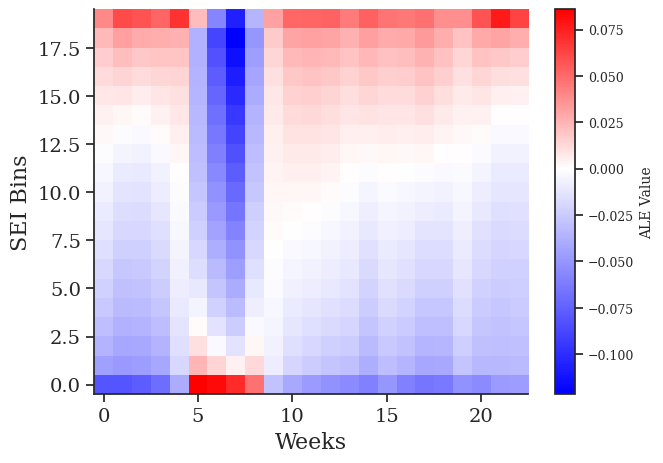

In [38]:
min_val = np.min(ale)
max_val = np.max(ale)
midpoint = abs(min_val) / (abs(max_val) + abs(min_val))

fig, ax = plt.subplots(figsize=(7,5))
colors = [(0, "blue"), (midpoint, "white"), (1, "red")]
linear_cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", colors)

HM = ax.imshow(ale.T, aspect='auto', cmap=linear_cmap, origin='lower', vmin=min_val, vmax=max_val)
cbar = fig.colorbar(HM, ax=ax)

ax.tick_params(axis='both', labelsize=14)  
ax.set_xlabel("Weeks", fontsize=16)
ax.set_ylabel("SEI Bins", fontsize=16)
cbar.ax.tick_params(labelsize=9)          
cbar.set_label("ALE Value", fontsize=10)    

## 2.2 Plot 2D ALE (conformity - Covid case)

In [4]:
# load data and model
dataset = load_data("../data/dataset2020/all_data_2020_dataset_with_substitute_confounders.h5")

# index_to_remove = dataset['covariates'].shape[2] - 5
# dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

# index_to_remove = dataset['covariates'].shape[2] - 5
# dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

# column_2020 = 13
# dataset20 = obtain_dataset(dataset, column_2020)
dataset20 = dataset_sampling(dataset, num_select=32000)

for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(327217, 161, 21)
float32
outcomes
(327217, 161, 1)
float32
predicted_confounders
(327217, 161, 1)
float32
previous_covariates
(327217, 160, 21)
float32
previous_treatments
(327217, 160, 3)
float32
sequence_length
(327217,)
int64
treatments
(327217, 161, 3)
float32


2025-11-01 23:18:50.725 | DEBUG    | ale:_second_order_ale_quant:599 - Quantiles: (array([ 0.       ,  2.782576 ,  3.2099729,  3.4928892,  3.7125225,
        3.8989825,  4.061941 ,  4.209889 ,  4.349026 ,  4.4828033,
        4.614274 ,  4.7452703,  4.8792324,  5.019635 ,  5.172307 ,
        5.3438554,  5.5457053,  5.795225 ,  6.122841 ,  6.609535 ,
       12.063708 ], dtype=float32), array([0.       , 0.6931472, 1.609438 , 2.3025851, 3.0445225, 4.1108737],
      dtype=float32)).


(array([ 0.       ,  2.782576 ,  3.2099729,  3.4928892,  3.7125225,
        3.8989825,  4.061941 ,  4.209889 ,  4.349026 ,  4.4828033,
        4.614274 ,  4.7452703,  4.8792324,  5.019635 ,  5.172307 ,
        5.3438554,  5.5457053,  5.795225 ,  6.122841 ,  6.609535 ,
       12.063708 ], dtype=float32), array([0.       , 0.6931472, 1.609438 , 2.3025851, 3.0445225, 4.1108737],
      dtype=float32))
(20, 5)
results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted_0.1_125_100_64_0.005_1.0_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-11-01 23:18:55.143288: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 500it [00:14, 34.91it/s]


results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted_0.1_125_100_64_0.005_1.0_60_optimal
Predicting rnn_propensity_weighted: 500it [00:14, 34.99it/s]


results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted_0.1_125_100_64_0.005_1.0_60_optimal
Predicting rnn_propensity_weighted: 500it [00:14, 34.68it/s]


results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_all_data_2020_v2_use_confounders_True/rnn_propensity_weighted/rnn_propensity_weighted_0.1_125_100_64_0.005_1.0_60_optimal
Predicting rnn_propensity_weighted: 500it [00:14, 34.69it/s]
2025-11-01 23:20:06.057 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         2.782576   3.2099729  3.4928892  3.7125225  3.8989825
  4.061941   4.209889   4.349026   4.4828033  4.614274   4.7452703
  4.8792324  5.019635   5.172307   5.3438554  5.5457053  5.795225
  6.122841   6.609535  12.063708 ].
2025-11-01 23:20:06.089 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [0.        0.6931472 1.609438  2.3025851 3.0445225 4.1108737].


plotting contour...


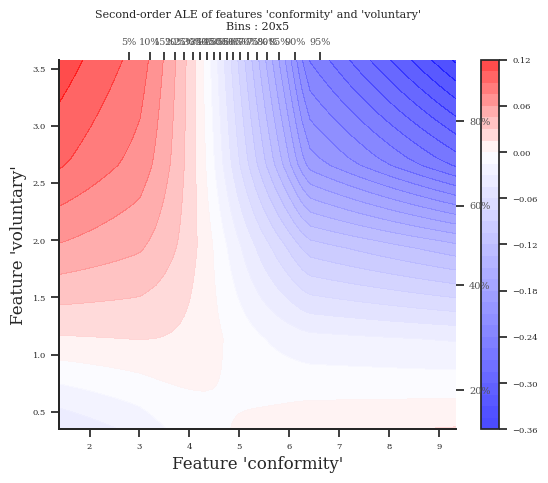

In [5]:
# compute 2-order interaction 
exp_name = "all_data_2020_v2"
_, ale, quantiles_list = compute_ale(dataset20, 'rmsn_' + str(exp_name), b_use_predicted_confounders=True, features=['conformity','voluntary'])

In [6]:
# construct xarray dataset
def create_2d_ale_dataset(ale_dict, quantiles_list, values, model_names, feature_names):
  
    # Take the average of adjacent quantiles
    centered_list = []
    for quantiles in quantiles_list:
        quantiles = (quantiles[:-1] + quantiles[1:]) / 2
        centered_list.append(quantiles)
    quantiles_list = centered_list

    # Create the data_vars dictionary
    data_vars = {}
    for model_name in model_names:
        ale = ale_dict[model_name]
        # Add an extra dimension to ALE
        ale = ale[np.newaxis, :]
        
        data_vars[f"{feature_names[0]}__{feature_names[1]}__{model_name}__ale"] = \
            (["n_bootstrap", f"n_bins__{feature_names[0]}", f"n_bins__{feature_names[1]}"], ale)

    for i in range(2):
        data_vars[f"{feature_names[i]}__bin_values"] = ([f"n_bins__{feature_names[i]}"], quantiles_list[i])
        data_vars[feature_names[i]] = (["n_X"], values[i].reshape(-1))

    # create xarray.Dataset
    dataset = xr.Dataset(
        data_vars=data_vars,
        attrs={
            "estimator_output": "raw",
            "estimators used": model_names,
            "method": "ale",
            "dimension": "2D",
            "features used": [(feature_names[0], feature_names[1])],
        }
    )

    return dataset

In [7]:
X = [dataset20['treatments'][:,:,0], dataset20['covariates'][:,:,10]]
ale_dict = {"RNN_Model": ale.filled(np.nan)}
model_names = ["RNN_Model"]
feature_names = ['conformity','voluntary']
ale_2d = create_2d_ale_dataset(ale_dict, quantiles_list, X, model_names, feature_names)

In [15]:
ale_2d

<xarray.Dataset>
Dimensions:                                (n_bootstrap: 1,
                                            n_bins__conformity: 20,
                                            n_bins__voluntary: 5, n_X: 5152000)
Dimensions without coordinates: n_bootstrap, n_bins__conformity,
                                n_bins__voluntary, n_X
Data variables:
    conformity__voluntary__RNN_Model__ale  (n_bootstrap, n_bins__conformity, n_bins__voluntary) float64 ...
    conformity__bin_values                 (n_bins__conformity) float32 1.391...
    conformity                             (n_X) float32 4.577 5.198 ... 5.784
    voluntary__bin_values                  (n_bins__voluntary) float32 0.3466...
    voluntary                              (n_X) float32 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    estimator_output:  raw
    estimators used:   ['RNN_Model']
    method:            ale
    dimension:         2D
    features used:     [('conformity', 'voluntary')]

In [17]:
ale_2d.to_zarr('figures/figure_data/fig_3b_SEIandCASE.zarr', mode='w')

In [20]:
import zarr

store = zarr.open('figures/figure_data/fig_3b_SEIandCASE.zarr', mode='r')
ale_2d = xr.open_dataset(store, engine='store')

AttributeError: 

In [24]:
def _second_order_quant_plot(fig, ax, quantiles_list, ale, mark_empty=True, n_interp=50, linear_cmap=None, **kwargs):
    # define colormap - let value 0 equals white
    min_val = np.min(ale)
    max_val = np.max(ale)
    midpoint = abs(min_val) / (abs(max_val) + abs(min_val))
    if linear_cmap is None:
        colors = [(0, "blue"), (midpoint, "white"), (1, "red")]
        linear_cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", colors)
    
    centres_list = [_get_centres(quantiles) for quantiles in quantiles_list]
    print("plotting contour...")
    n_x, n_y = _check_two_ints(n_interp)
    x = np.linspace(centres_list[0][0], centres_list[0][-1], n_x)
    y = np.linspace(centres_list[1][0], centres_list[1][-1], n_y)

    X, Y = np.meshgrid(x, y, indexing="xy")
    ale_interp = scipy.interpolate.interp2d(centres_list[0], centres_list[1], ale.T)
    # CF = ax.contourf(X, Y, ale_interp(x, y), cmap="bwr", levels=30, alpha=0.7, **kwargs)
    CF = ax.contourf(X, Y, ale_interp(x, y), cmap=linear_cmap, vmin=min_val, vmax=max_val, levels=30, alpha=0.7, **kwargs)

    if mark_empty and np.any(ale.mask):
        # Do not autoscale, so that boxes at the edges (contourf only plots the bin
        # centres, not their edges) don't enlarge the plot.
        plt.autoscale(False)
        # Add rectangles to indicate cells without samples.
        for i, j in zip(*np.where(ale.mask)):
            ax.add_patch(
                Rectangle(
                    [quantiles_list[0][i], quantiles_list[1][j]],
                    quantiles_list[0][i + 1] - quantiles_list[0][i],
                    quantiles_list[1][j + 1] - quantiles_list[1][j],
                    linewidth=1,
                    edgecolor="k",
                    facecolor="none",
                    alpha=0.4,
                )
            )
    
    # fig.colorbar(CF)
    return fig, ax, CF

In [15]:
def _ax_quantiles(ax, quantiles, twin="x", num_ticks=10):
    
    if twin not in ("x", "y"):
        raise ValueError("'twin' should be one of 'x' or 'y'.")

    # logger.debug("Quantiles: {}.", quantiles)
    if len(quantiles) > 10:
        step = max(1, len(quantiles) // num_ticks)
        selected_indices = np.arange(0, len(quantiles), step)
        quantiles = quantiles[selected_indices]

    # Duplicate the 'opposite' axis so we can define a distinct set of ticks for the
    # desired axis (`twin`).
    ax_mod = ax.twiny() if twin == "x" else ax.twinx()

    # Set the new axis' ticks for the desired axis.
    getattr(ax_mod, "set_{twin}ticks".format(twin=twin))(quantiles)
    # Set the corresponding tick labels.

    # Calculate tick label percentage values for each quantile (bin edge).
    percentages = (
        100 * np.arange(len(quantiles), dtype=np.float64) / (len(quantiles) - 1)
    )

    # If there is a fractional part, add a decimal place to show (part of) it.
    fractional = (~np.isclose(percentages % 1, 0)).astype("int8")

    getattr(ax_mod, "set_{twin}ticklabels".format(twin=twin))(
        [
            "{0:0.{1}f}%".format(percent, format_fraction)
            for percent, format_fraction in zip(percentages, fractional)
        ],
        color="#545454",
        fontsize=7,
    )
    getattr(ax_mod, "set_{twin}lim".format(twin=twin))(
        getattr(ax, "get_{twin}lim".format(twin=twin))()
    )
    
    ax_mod.tick_params(axis=twin, length=2)

In [16]:
def add_histogram_axis(
        ax,
        data,
        bins=15,
        min_value=None,
        max_value=None,
        density=True,
        orientation="vertical",
        **kwargs,
    ):
    
        color = kwargs.get("color", "xkcd:steel")
        edgecolor = kwargs.get("edgecolor", "white")

        hist_values, bin_edges = np.histogram(data, bins=bins)
        print(hist_values, bin_edges)
        if orientation=='vertical':
            ax.bar(bin_edges[:-1], hist_values, width=np.diff(bin_edges), align='edge',
               alpha=0.35, color=color, edgecolor=edgecolor, zorder=1)
        else:
            ax.barh(bin_edges[:-1], hist_values, height=np.diff(bin_edges), align='edge',
               alpha=0.35, color=color, edgecolor=edgecolor, zorder=1)

In [17]:
def plot_2d_kde(ax, x, y):
        """
        Add contours of the kernel density estimate
        """
        xmin, xmax = np.min(x), np.max(x)
        ymin, ymax = np.min(y), np.max(y)

        # Peform the kernel density estimate
        xx, yy = np.mgrid[xmin:xmax:50j, ymin:ymax:50j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        values = np.vstack([x, y])
        kernel = sps.gaussian_kde(values)
        f = np.reshape(kernel(positions).T, xx.shape)

        percentiles = [50.0, 75.0, 90.0]
        linewidths = [
            0.25,
            0.75,
            1.5,
        ]
        line_colors = ["xkcd:indigo", "xkcd:dark cyan", "xkcd:dandelion"]
        levels = np.zeros((len(percentiles)))
        for i in range(len(percentiles)):
            levels[i] = np.percentile(f.ravel(), percentiles[i])

        # Contour plot
        cset = ax.contour(
            xx,
            yy,
            f,
            levels=levels,
            linewidths=linewidths,
            colors=line_colors,
        )
        fmt = {}
        for l, s in zip(cset.levels, percentiles[::-1]):
            fmt[l] = f"{int(s)}"

        ax.clabel(cset, cset.levels, inline=True, fontsize=6, fmt=fmt)

In [18]:
def get_twinx(ax):
    for ax2 in ax.figure.axes:
        if ax2 is not ax and ax.get_shared_x_axes().joined(ax, ax2):
            return ax2
    return None

def get_twiny(ax):
    for ax2 in ax.figure.axes:
        if ax2 is not ax and ax.get_shared_y_axes().joined(ax, ax2):
            return ax2
    return None

In [20]:
midpoint

0.7556818858130974

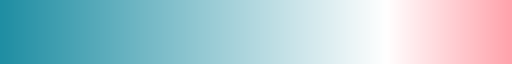

In [32]:
# define colorbar
colors = ["#ffa3ac", "#ffc0c2", "#ffdab9", "#6dc9c8", "#1f8ea3"]

# Compute the center point of the ALE data
min_val = np.min(ale)
max_val = np.max(ale)
midpoint = abs(min_val) / (abs(max_val) + abs(min_val))

# Insert white at the center to achieve a smooth transition
# e.g. [red → pink → white → cyan → blue]
colors = [
    (0.0, "#1f8ea3"),   # light red
    # (0.25, "#ffc0c2"),   # pink
    (midpoint, "w"), # central white
    # (0.85, "#6dc9c8"),  # light cyan
    (1.0, "#ffa3ac"),   # dark blue
]

# Create a gradient colormap
my_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
my_cmap

plotting contour...


`interp2d` is deprecated!
`interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.12.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://gist.github.com/ev-br/8544371b40f414b7eaf3fe6217209bff`

        `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.12.0.

        For legacy code, nearly bug-for-bug compatible replacements are
        `RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
        scattered 2D data.

        In new code, for regular grids use `RegularGridInterpolator` instead.
        For scattered data, prefer `LinearNDInterpolator` or
        `CloughTocher2DInterpolator`.

        For more details see


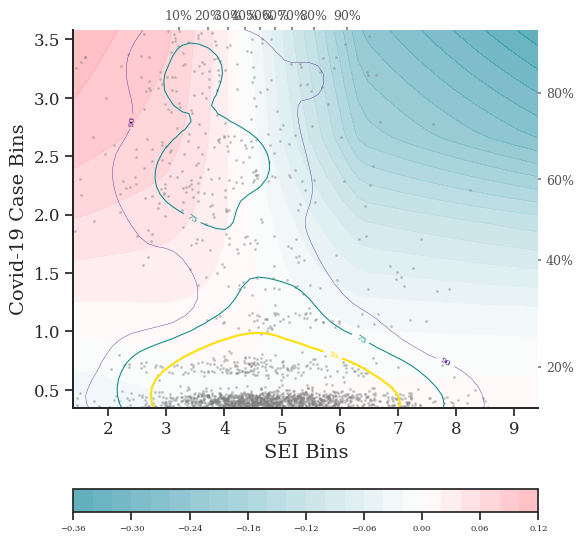

In [33]:
data = ale_2d
fig, ax = plt.subplots(figsize=(6,7))
fig, ax, cf = _second_order_quant_plot(fig, ax, quantiles_list, ale, linear_cmap=my_cmap)
for twin, quantiles in zip(("x", "y"), quantiles_list):
    _ax_quantiles(ax, quantiles, twin=twin)

xdata1 = data[f"{feature_names[0]}__bin_values"].values
xdata2 = data[f"{feature_names[1]}__bin_values"].values

xdata1_hist = data[f"{feature_names[0]}"].values
xdata2_hist = data[f"{feature_names[1]}"].values

add_hist = False; scatter = True; kde_curves = True;

if add_hist:
    # Create a new axis for plotting the histogram
    top_ax = ax.inset_axes([0, 1.08, 1, 0.2], transform=ax.transAxes)
    rhs_ax = ax.inset_axes([1.08, 0, 0.2, 1], transform=ax.transAxes)

    add_histogram_axis(
        top_ax,
        xdata1_hist,
        bins=15,
        orientation="vertical",
        min_value=xdata1[1],
        max_value=xdata1[-2],
        color="xkcd:steel",
        edgecolor="white"
    )
    # Add the histogram on the right side
    add_histogram_axis(
        rhs_ax,
        xdata2_hist,
        bins=5,
        orientation="horizontal",
        min_value=xdata2[1],
        max_value=xdata2[-2],
        color="xkcd:steel",
        edgecolor="white"
    )

    # Hide axis ticks, labels, and spines
    top_ax.xaxis.set_visible(False)
    top_ax.yaxis.set_visible(False)
    top_ax.spines['top'].set_visible(False)
    top_ax.spines['right'].set_visible(False)
    top_ax.spines['left'].set_visible(False)
    top_ax.spines['bottom'].set_visible(False)
    top_ax.tick_params(axis='x', which='both')
    top_ax.tick_params(axis='y', which='both')

    rhs_ax.xaxis.set_visible(False)
    rhs_ax.yaxis.set_visible(False)
    rhs_ax.spines['top'].set_visible(False)
    rhs_ax.spines['right'].set_visible(False)
    rhs_ax.spines['left'].set_visible(False)
    rhs_ax.spines['bottom'].set_visible(False)
    rhs_ax.tick_params(axis='x', which='both', labelbottom=False)
    rhs_ax.tick_params(axis='y', which='both', labelleft=False)

if scatter:
    # Random sampling
    idx = np.random.choice(len(xdata1_hist), size=min(2000, len(xdata1_hist)))
    
    # Get the axis limits and clip accordingly
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xdata1_filtered = np.clip(xdata1_hist[idx], xlim[0]+0.05, xlim[1]-0.05)
    xdata2_filtered = np.clip(xdata2_hist[idx], ylim[0]+0.05, ylim[1]-0.05)
    
    # Add random jitter
    xdata1_jittered = xdata1_filtered + np.random.normal(0, 0.05, size=len(xdata1_filtered))
    xdata2_jittered = xdata2_filtered + np.random.normal(0, 0.05, size=len(xdata2_filtered))

    ax.scatter(xdata1_jittered, xdata2_jittered, alpha=0.3, color="grey", s=1.5,)
    # idx = np.random.choice(
    #                     len(xdata1_hist), size=min(2000, len(xdata1_hist))
    #                 )
    # xdata1_clipped = np.clip(xdata1_hist[idx], ax.get_xlim()[0]+0.05, ax.get_xlim()[1]-0.05)
    # xdata2_clipped = np.clip(xdata2_hist[idx], ax.get_ylim()[0]+0.05, ax.get_ylim()[1]-0.05)
    # ax.scatter(xdata1_clipped, xdata2_clipped, alpha=0.3, color="grey", s=3)
    # ax.scatter(xdata1_hist[idx], xdata2_hist[idx], alpha=0.3, color="grey", s=1)

if kde_curves:
    # There can be very rare cases where two functions are linearly correlated (cc~1.0)
    # which can cause the KDE calculations to fail!
    # xdata1_clipped = np.clip(xdata1_hist, ax.get_xlim()[0]+0.05, ax.get_xlim()[1]-0.05)
    # xdata2_clipped = np.clip(xdata2_hist, ax.get_ylim()[0]+0.05, ax.get_ylim()[1]-0.05)
    plot_2d_kde(ax, xdata1_jittered, xdata2_jittered)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("SEI Bins", fontsize=14)
ax.set_ylabel("Covid-19 Case Bins", fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax_right = get_twinx(ax)
if ax_right:
    ax_right.tick_params(axis='y', labelsize=9, color='grey')
    
ax_top = get_twiny(ax)
if ax_top:
    ax_top.tick_params(axis='x', labelsize=9, color='grey')
fig.colorbar(cf, ax=ax, orientation='horizontal')
plt.show()

## 2.3 Policy & SEI

In [15]:
dataset = load_data("../data/sample_3w2_add.h5")
index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(96000, 161, 23)
float32
outcomes
(96000, 161, 1)
float32
sequence_length
(96000,)
int64
treatments
(96000, 161, 1)
float32


In [16]:
column_2020 = 13  # index of year 2020 indicator
dataset20 = obtain_dataset(dataset, column_2020)
# dataset20 = dataset_sampling(dataset20, num_select=10000)

del dataset; gc.collect()
E1_index = 21; E2_index = 22;
dataset_counterfactual = copy.deepcopy(dataset20)
dataset_counterfactual['covariates'][:, :, E1_index] = 0
dataset_counterfactual2 = copy.deepcopy(dataset20)
dataset_counterfactual2['covariates'][:, :, E2_index] = 0

2025-11-01 19:24:22.472 | DEBUG    | ale:_second_order_ale_quant:481 - Quantiles: [ 0.         2.791647   3.218876   3.4991727  3.7191315  3.9042556
  4.067552   4.215221   4.3537126  4.48722    4.61823    4.7488556
  4.882308   5.0232496  5.175658   5.3464994  5.5468845  5.793752
  6.1199164  6.5996885 12.502842 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-11-01 19:24:26.182045: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 500it [00:13, 35.84it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 500it [00:14, 34.92it/s]


...

results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 500it [00:13, 36.28it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 500it [00:13, 36.86it/s]


plotting heatmap...


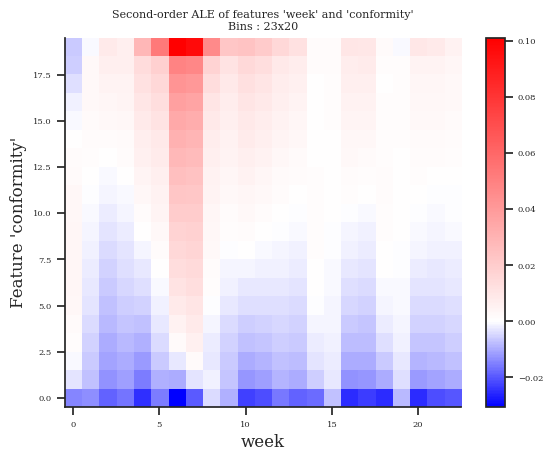

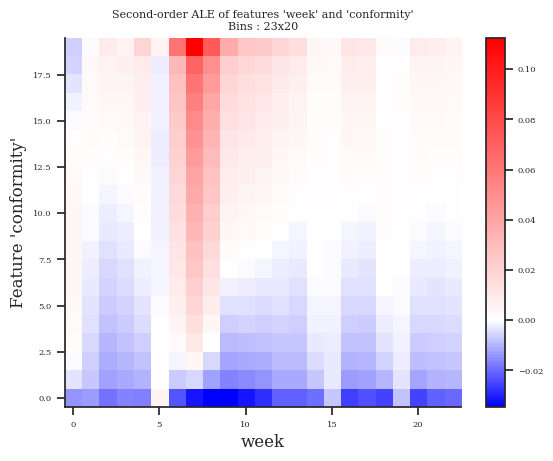

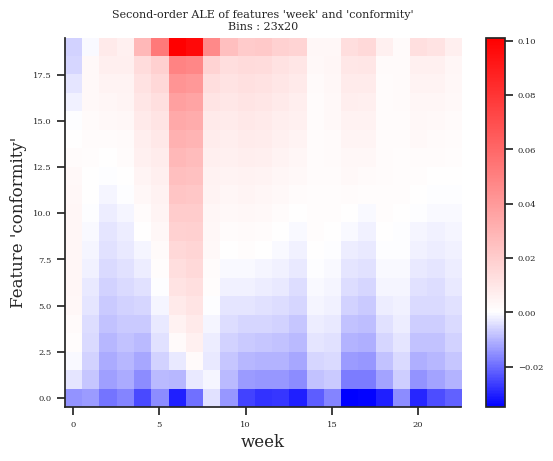

In [17]:
exp_name = "base_model_optimal_v2"
_, ale_raw , _ = compute_ale(dataset20, 'rmsn_' + str(exp_name), b_use_predicted_confounders=False, features=['week','conformity'])
_, ale_E1 , _ = compute_ale(dataset_counterfactual, 'rmsn_' + str(exp_name), b_use_predicted_confounders=False, features=['week','conformity'])
_, ale_E2 , _ = compute_ale(dataset_counterfactual2, 'rmsn_' + str(exp_name), b_use_predicted_confounders=False, features=['week','conformity'])

In [10]:
ale_raw = np.load("figures/figure_data/fig_3c_ale_2020_for_policy_effect.npy")
ale_E1 = np.load("figures/figure_data/fig_3c_ale_2020_without_E1.npy")
ale_E2 = np.load("figures/figure_data/fig_3c_ale_2020_without_E2.npy")

In [18]:
quantile =  [0.0, 2.7879772, 3.211453, 3.4923055, 3.7121875, 3.8972805, 4.0597386, 4.207221, 4.345022, 4.477929, 4.607671, 4.737211, 4.8709445, 5.0111146, 5.163077, 5.3334966, 5.533642, 5.7841897, 6.1140885, 6.6004605, 12.435878]
quantile = np.array(quantile)

In [11]:
# 选择时间段（E1:20200124-20200223; E2: 20200224-20200508）
def select_intervention_data(ale, start_target_date, end_target_date, start_date=pd.Timestamp('2019-12-21')):

    start_target_date = pd.Timestamp(start_target_date)
    end_target_date = pd.Timestamp(end_target_date)

    start_week = ((start_target_date - start_date).days // 7)
    end_week = ((end_target_date - start_date).days // 7)

    # 提取ale数组中相应的行
    ale_subset = ale[start_week:end_week + 1]
    return ale_subset

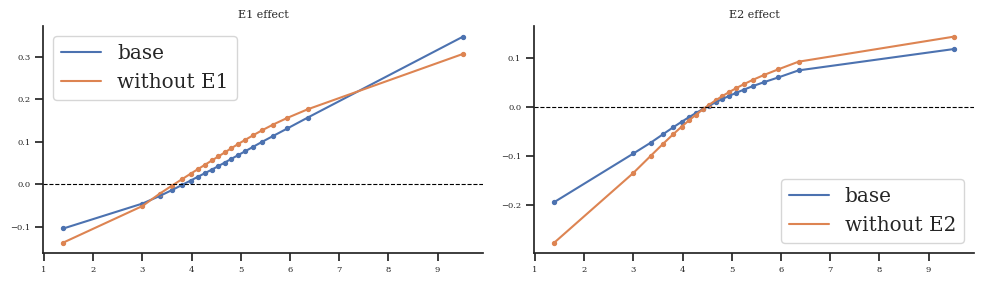

In [20]:
ale_raw_sub1 = select_intervention_data(ale_raw, '2020-01-24', '2020-02-23')
ale_E1_sub = select_intervention_data(ale_E1, '2020-01-24', '2020-02-23')
ale_raw_sub2 = select_intervention_data(ale_raw, '2020-02-24', '2020-05-08')
ale_E2_sub = select_intervention_data(ale_E2, '2020-02-24', '2020-05-08')

fig, ax = plt.subplots(1,2,figsize=(10, 3))

ax[0].plot(_get_centres(quantile), np.sum(ale_raw_sub1, axis=0), label='base')
ax[0].plot(_get_centres(quantile), np.sum(ale_E1_sub, axis=0), label='without E1')

ax[0].scatter(_get_centres(quantile), np.sum(ale_raw_sub1, axis=0), s=8)
ax[0].scatter(_get_centres(quantile), np.sum(ale_E1_sub, axis=0), s=8)

ax[0].legend(fontsize='large')
ax[0].set_title("E1 effect")

ax[1].plot(_get_centres(quantile), np.sum(ale_raw_sub2, axis=0), label='base')
ax[1].plot(_get_centres(quantile), np.sum(ale_E2_sub, axis=0), label='without E2')

ax[1].scatter(_get_centres(quantile), np.sum(ale_raw_sub2, axis=0), s=8)
ax[1].scatter(_get_centres(quantile), np.sum(ale_E2_sub, axis=0), s=8)

ax[1].legend(fontsize='large')
ax[1].set_title("E2 effect")

# Adding y=0 line
for axis in ax:
    axis.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

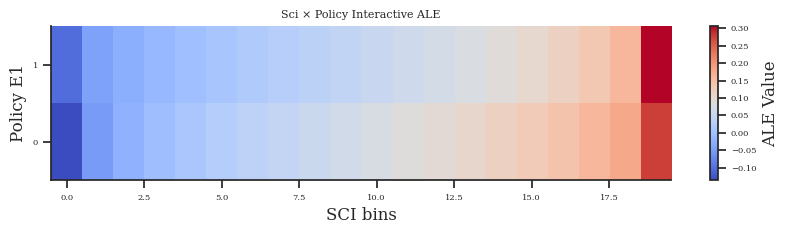

In [12]:
data_0 =  np.sum(ale_E1_sub, axis=0)
data_1 = np.sum(ale_raw_sub1, axis=0)

# Combine data_0 and data_1 into a single array for heatmap
data_combined = np.vstack((data_0, data_1))

# Create heatmap
plt.figure(figsize=(10, 2))
plt.imshow(data_combined, cmap='coolwarm', aspect='auto', origin='lower')
plt.colorbar(label='ALE Value')
plt.yticks([0, 1])
plt.ylabel('Policy E1')
plt.xlabel('SCI bins')
plt.title('Sci × Policy Interactive ALE')
plt.show()

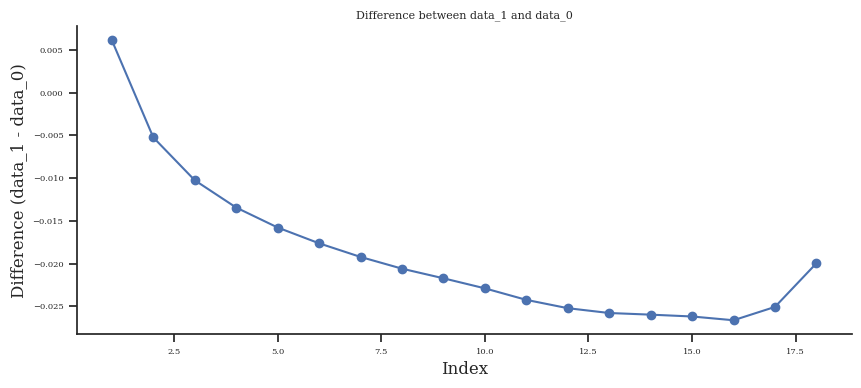

In [13]:
# Calculate the difference between data_1 and data_0
data_diff = data_1 - data_0

# Create a plot of the difference
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1,19),data_diff[1:-1], marker='o', linestyle='-', color='b')
plt.xlabel('Index')
plt.ylabel('Difference (data_1 - data_0)')
plt.title('Difference between data_1 and data_0')
# plt.grid(True)
plt.show()

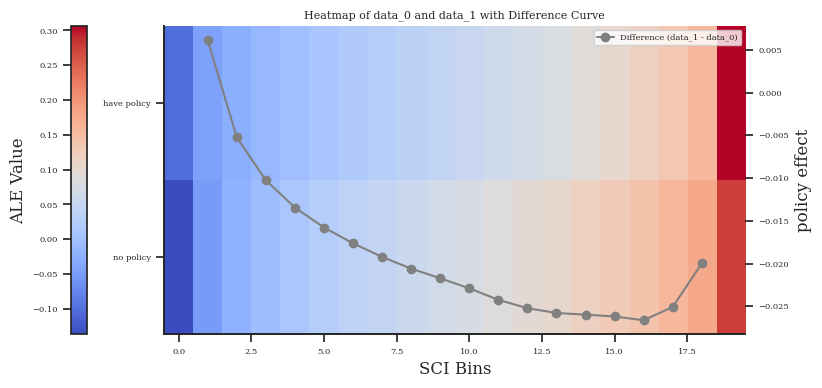

In [14]:
data_diff = data_1 - data_0

# Create a combined plot with the heatmap and the difference curve
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot the heatmap
cax = ax1.imshow(data_combined, cmap='coolwarm', aspect='auto', origin='lower')
fig.colorbar(cax, ax=ax1, label='ALE Value', location='left')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['no policy', 'have policy'])
ax1.set_xlabel('SCI Bins')
ax1.set_title('Heatmap of data_0 and data_1 with Difference Curve')

# Create a secondary axis for the difference curve
ax2 = ax1.twinx()
ax2.plot(np.arange(1,19),data_diff[1:-1], marker='o', linestyle='-', color='grey', label='Difference (data_1 - data_0)')
ax2.set_ylabel('policy effect')
ax2.legend(loc='upper right')

plt.show()

In [4]:
# ale_raw = ale_raw.filled(np.nan)
# ale_E1 = ale_E1.filled(np.nan)
# ale_E2 = ale_E2.filled(np.nan)

# np.save("figures/figure_data/ale_2020_for_policy_effect.npy", ale_raw)
# np.save("figures/figure_data/ale_2020_without_E1.npy", ale_E1)
# np.save("figures/figure_data/ale_2020_without_E2.npy", ale_E2)